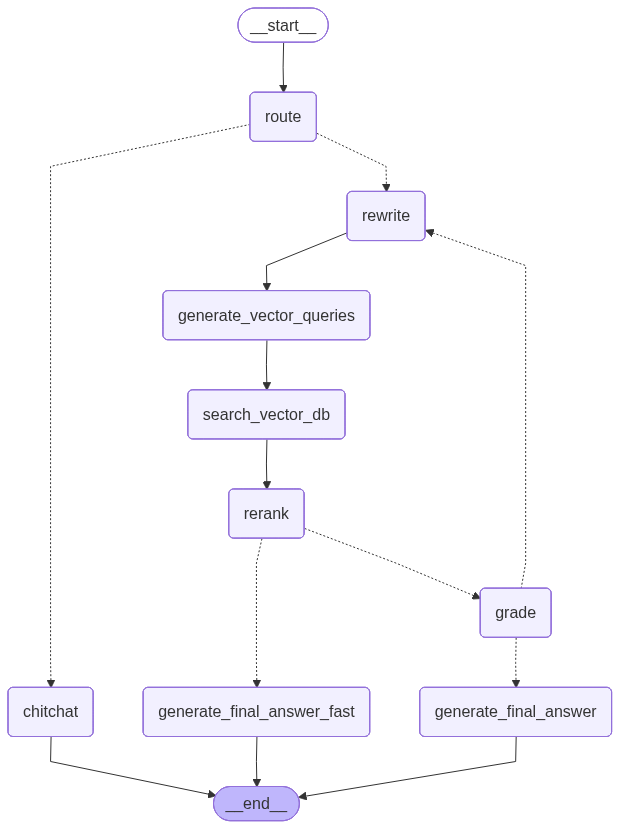

In [1]:
import sys
sys.path.append("..")

from IPython.display import Image, display
from langgraph.graph import END, StateGraph

from catchup.rag.state import AgentState
from catchup.rag.conditional_edges import route_after_grade, route_after_rerank, route_question

# 실제 LLM/서비스 초기화 없이 구조만 구성
async def _noop(*args, **kwargs):
    return {}

workflow = StateGraph(AgentState)

for name in [
    "route", "rewrite", "generate_vector_queries",
    "search_vector_db", "rerank", "grade",
    "chitchat", "generate_final_answer", "generate_final_answer_fast",
]:
    workflow.add_node(node=name, action=_noop)

workflow.set_entry_point("route")
workflow.add_conditional_edges("route", route_question, {"rewrite": "rewrite", "chitchat": "chitchat"})
workflow.add_edge("chitchat", END)
workflow.add_edge("rewrite", "generate_vector_queries")
workflow.add_edge("generate_vector_queries", "search_vector_db")
workflow.add_edge("search_vector_db", "rerank")
workflow.add_conditional_edges("rerank", route_after_rerank, {
    "generate_final_answer_fast": "generate_final_answer_fast",
    "grade": "grade",
})
workflow.add_edge("generate_final_answer_fast", END)
workflow.add_conditional_edges("grade", route_after_grade, {
    "generate_final_answer": "generate_final_answer",
    "rewrite": "rewrite",
})
workflow.add_edge("generate_final_answer", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))